In [1]:
# Load radargrams over David Glacier from KOPRI
# Uses manually edited version of impdar to read segy files using endian='big' instead of the default 'little'

from impdar.lib import load, plot # Use obspy instead as segy
from obspy.io.segy.core import _read_segy
import os
from impdar.lib.plot import plot_traces, plot_radargram

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

%matplotlib inline
%load_ext autoreload
%autoreload 2


import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import cartopy.crs as ccrs

import segyio
import shapefile
import shapely
import xarray as xr

In [2]:
# Load utig netcdf files
utig_path = './_data/UTG_Complex'
file_paths = [os.path.join(utig_path, f) for f in os.listdir(utig_path) if f.endswith('.nc')]

utig_radargrams = []
for f in file_paths[:]:
    utig_radargram = xr.open_dataset(f)
    utig_radargrams.append(utig_radargram)


/tmp/ipykernel_1965/842517954.py:7: FutureWarning: In a future version, xarray will not decode the variable 'fast_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  utig_radargram = xr.open_dataset(f)
/tmp/ipykernel_1965/842517954.py:7: FutureWarning: In a future version, xarray will not decode the variable 'fast_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To conti

In [3]:
utig_radargrams[0]

<xarray.Dataset> Size: 845MB
Dimensions:    (distance: 21988, fast_time: 3200)
Coordinates:
  * distance   (distance) float64 176kB 0.0 1.0 2.0 ... 2.199e+04 2.199e+04
  * fast_time  (fast_time) timedelta64[ns] 26kB 00:00:00 ... 00:00:00.000063980
Data variables:
    x          (distance) float64 176kB ...
    y          (distance) float64 176kB ...
    h          (distance) float64 176kB ...
    time       (distance) datetime64[ns] 176kB ...
    bxds5      (distance, fast_time) int16 141MB ...
    bxds6      (distance, fast_time) int16 141MB ...
    bxds7      (distance, fast_time) int16 141MB ...
    bxds8      (distance, fast_time) int16 141MB ...
    bxds2      (distance, fast_time) int16 141MB ...
    bxds1      (distance, fast_time) int16 141MB ...
Attributes: (12/13)
    transect_id:     D2DG/IBH0e/X37a
    history:         Created on Sun Jan  4 17:00:53 2026 by Duncan A. Young
    funding:         KOPRI/K-ROUTE
    expedition:      KRT2
    platform:        AS-350 helicopter
    radar:           HeRa
    ...              ...
    sample_rate_hz:  50000000.0
    chirp_start_hz:  17500000.0
    chirp_end_hz:    2500000.0
    lo_gain_dbm:     82.7
    high_gain_dbm:   128.7
    reference:       http://doi.org/10.26153/tsw/11620

In [4]:
# Load Lake Cheongsuk shapefile
sld_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/_Semesters/25FA/KOPRI/SLD2'
pathA = sld_path + '/SLD2-A.shp'
pathB = sld_path + '/SLD2-B.shp'
pathC = sld_path + '/SLD2-C.shp'

xs_lake = []
ys_lake = []
for path in [pathA, pathB, pathC]:
    sf = shapefile.Reader(path)
    shapes = sf.shapes()
    for shp in shapes:
        points = shp.points
        x = [p[0] for p in points]
        y = [p[1] for p in points]
    xs_lake.append(x)
    ys_lake.append(y)


In [5]:
# Set up plan view plotting function
def plot_radargram_planview(ax, radargrams, xs_lake, ys_lake):
    bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full

    ax.patch.set_facecolor("none")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    for radargram in utig_radargrams[:]:
        ax.plot(radargram.x, radargram.y, color='red', zorder=3, transform=ps71_projection,linewidth=1)
        #print(radargram.transect_id.split('/')[-1])
        ax.text(radargram.x[0], radargram.y[0], radargram.transect_id.split('/')[-1], color='red', fontsize=10, transform=ps71_projection, zorder=5)

    for x, y in zip(xs_lake, ys_lake):
        ax.plot(x, y, color='blue', linewidth=1, zorder=0)

    ax.set_xlim(bbox[0],bbox[2])
    ax.set_ylim(bbox[1],bbox[3])



In [6]:
# Compare plan view to unprocessed
file_paths_18_19 = [os.path.join('./_data/IPR_2018-2019', f) for f in os.listdir('./_data/IPR_2018-2019') if f.endswith('.segy')]
file_paths_18_19.sort()
radargrams_18_19 = [load.load('segy',file_paths_18_19[i]) for i in range(len(file_paths_18_19[:]))]
names = [path.split('/')[-1].split('.')[0] for path in file_paths_18_19]

In [7]:
utig_radargrams.sort(key=lambda x: x.transect_id)

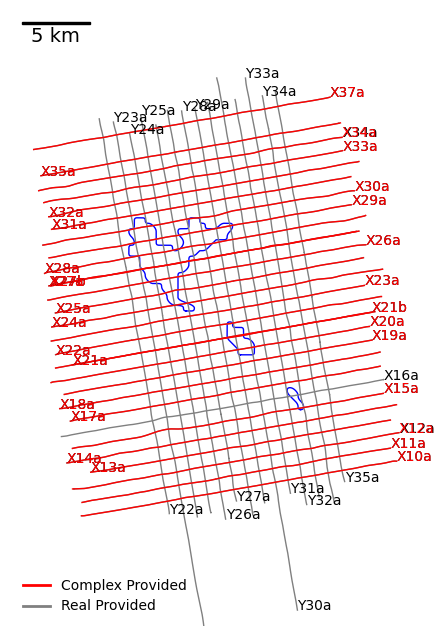

In [9]:
# Plot plan view comparison
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': ps71_projection})

plot_radargram_planview(ax, utig_radargrams, xs_lake, ys_lake)
for radargram in radargrams_18_19[:]:
    ax.plot(radargram[0].x_coord, radargram[0].y_coord, color='gray', zorder=2, linewidth=1)
    ax.text(radargram[0].x_coord[0]*1, radargram[0].y_coord[0]*1, names[radargrams_18_19.index(radargram)], color='black', fontsize=10, transform=ps71_projection, zorder=3)

# Make single legend
legend_elements = [plt.Line2D([0], [0], color='red', lw=2, label='Complex Provided'),
                   plt.Line2D([0], [0], color='gray', lw=2, label='Real Provided'),
]
ax.legend(handles=legend_elements, loc='lower left')
ax.get_legend().get_frame().set_edgecolor('none')

scalebar = AnchoredSizeBar(ax.transData, 5000, '5 km', 'upper left', 
                           pad=0.5, color='black', frameon=False, size_vertical=200, fontproperties={'size': 14})
ax.add_artist(scalebar)


In [137]:
# Find X29a in utig_radargrams
for radargram in utig_radargrams:
    if radargram.transect_id.split('/')[-1] == 'X23a':
        x29a_utig = radargram
for name in names:
    if name == 'X23a':
        x29a_18_19 = radargrams_18_19[names.index(name)][0]
        x_start = x29a_18_19.x_coord[0]
        y_start = x29a_18_19.y_coord[0]
        dist_along_track = np.sqrt((x29a_18_19.x_coord - x_start)**2 + (x29a_18_19.y_coord - y_start)**2)

In [138]:
def plot_radargram_xsect(ax, analytic, vmin, vmax):
    # Scale to dB
    eps = 1e-20
    amp = np.abs(analytic)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)
    print(np.min(rad_db), np.max(rad_db))
    im = ax.imshow(rad_db.T,aspect='auto',cmap='gray',vmin=vmin,vmax=vmax)

    cb = fig.colorbar(im, ax=ax, label="Amplitude [dB]")
    ax.set_ylabel("Fast time [ns]",fontsize=16)
    ax.set_xlabel("Along Track Distance [m]",fontsize=16)
    ax.tick_params(labelsize=14)
    cb.ax.tick_params(labelsize=14)
    cb.set_label("Relative Return [dB]", fontsize=16)

In [139]:
# pick one channel
data = x29a_utig['bxds2'].compute().astype(np.float32)
# Hilbert along fast_time axis
analytic = hilbert(data, axis=1)

In [140]:
x29a_utig

<xarray.Dataset> Size: 893MB
Dimensions:    (distance: 23238, fast_time: 3200)
Coordinates:
  * distance   (distance) float64 186kB 0.0 1.0 2.0 ... 2.324e+04 2.324e+04
  * fast_time  (fast_time) timedelta64[ns] 26kB 00:00:00 ... 00:00:00.000063980
Data variables:
    x          (distance) float64 186kB 6.759e+05 6.759e+05 ... 6.53e+05
    y          (distance) float64 186kB -1.45e+06 -1.45e+06 ... -1.454e+06
    h          (distance) float64 186kB ...
    time       (distance) datetime64[ns] 186kB ...
    bxds6      (distance, fast_time) int16 149MB ...
    bxds7      (distance, fast_time) int16 149MB ...
    bxds5      (distance, fast_time) int16 149MB ...
    bxds1      (distance, fast_time) int16 149MB ...
    bxds2      (distance, fast_time) int16 149MB ...
    bxds8      (distance, fast_time) int16 149MB ...
Attributes: (12/13)
    transect_id:     D2DG/IBH0e/X23a
    history:         Created on Sun Jan  4 16:53:23 2026 by Duncan A. Young
    funding:         KOPRI/K-ROUTE
    expedition:      KRT2
    platform:        AS-350 helicopter
    radar:           HeRa
    ...              ...
    sample_rate_hz:  50000000.0
    chirp_start_hz:  17500000.0
    chirp_end_hz:    2500000.0
    lo_gain_dbm:     82.7
    high_gain_dbm:   128.7
    reference:       http://doi.org/10.26153/tsw/11620

-173.70636 0.0


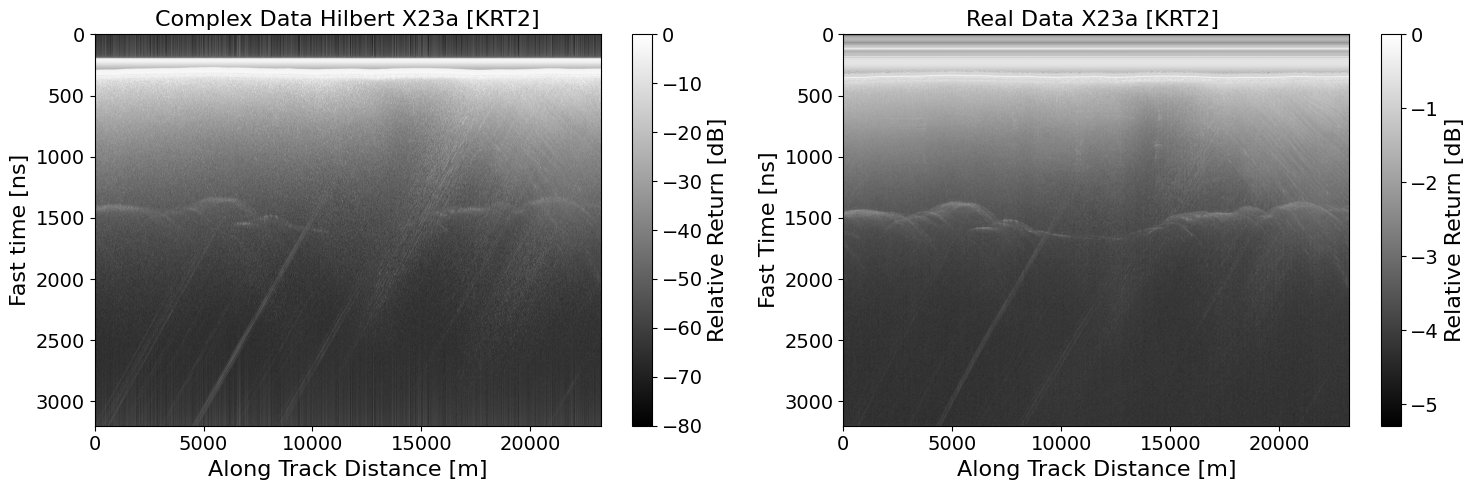

In [141]:
# Compare plots of X29a
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
ax1, ax2 = axs.ravel()
plot_radargram_xsect(ax1, analytic, vmin=-80, vmax=0)
ax1.set_title('Complex Data Hilbert X23a [KRT2]', fontsize=16)

amp = x29a_18_19.data
eps = 1e-20 
amp = amp / np.max(amp)
rad_db = 20 * np.log10(amp + eps)
im = ax2.imshow(rad_db, aspect='auto', cmap='gray', extent=[dist_along_track[0], dist_along_track[-1], x29a_18_19.travel_time[-1]/20, x29a_18_19.travel_time[0]/20])
cb = fig.colorbar(im, ax=ax2)
cb.set_label('Relative Return [dB]', fontsize=16)
ax2.set_xlabel('Along Track Distance [m]',fontsize=16)
ax2.set_ylabel('Fast Time [ns]',fontsize=16)
ax2.tick_params(labelsize=14)
cb.ax.tick_params(labelsize=14)
ax2.set_title('Real Data X23a [KRT2] ', fontsize=16)

fig.subplots_adjust(hspace=0.5) 
fig.tight_layout()
fig.savefig('X23a_Comparison.png', dpi=300)


In [25]:
# Load utig netcdf
import xarray as xr
utig_path = './_data/*Y44a.nc'
utig_radargram = xr.open_mfdataset(utig_path, combine='by_coords')
utig_radargram


# pick one channel
data = utig_radargram['bxds1'].compute().astype(np.float32)

# Hilbert along fast_time axis
analytic_y44a = hilbert(data, axis=1)
eps = 1e-20
amp = np.abs(analytic_y44a)  
amp = amp / np.max(amp)
rad_db_y44a = 20 * np.log10(amp + eps)


/tmp/ipykernel_2379/3276275796.py:4: FutureWarning: In a future version, xarray will not decode the variable 'fast_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  utig_radargram = xr.open_mfdataset(utig_path, combine='by_coords')


In [31]:
analytic.shape

(23629, 3200)

In [33]:
x29a_18_19.data.shape

(3200, 2848)

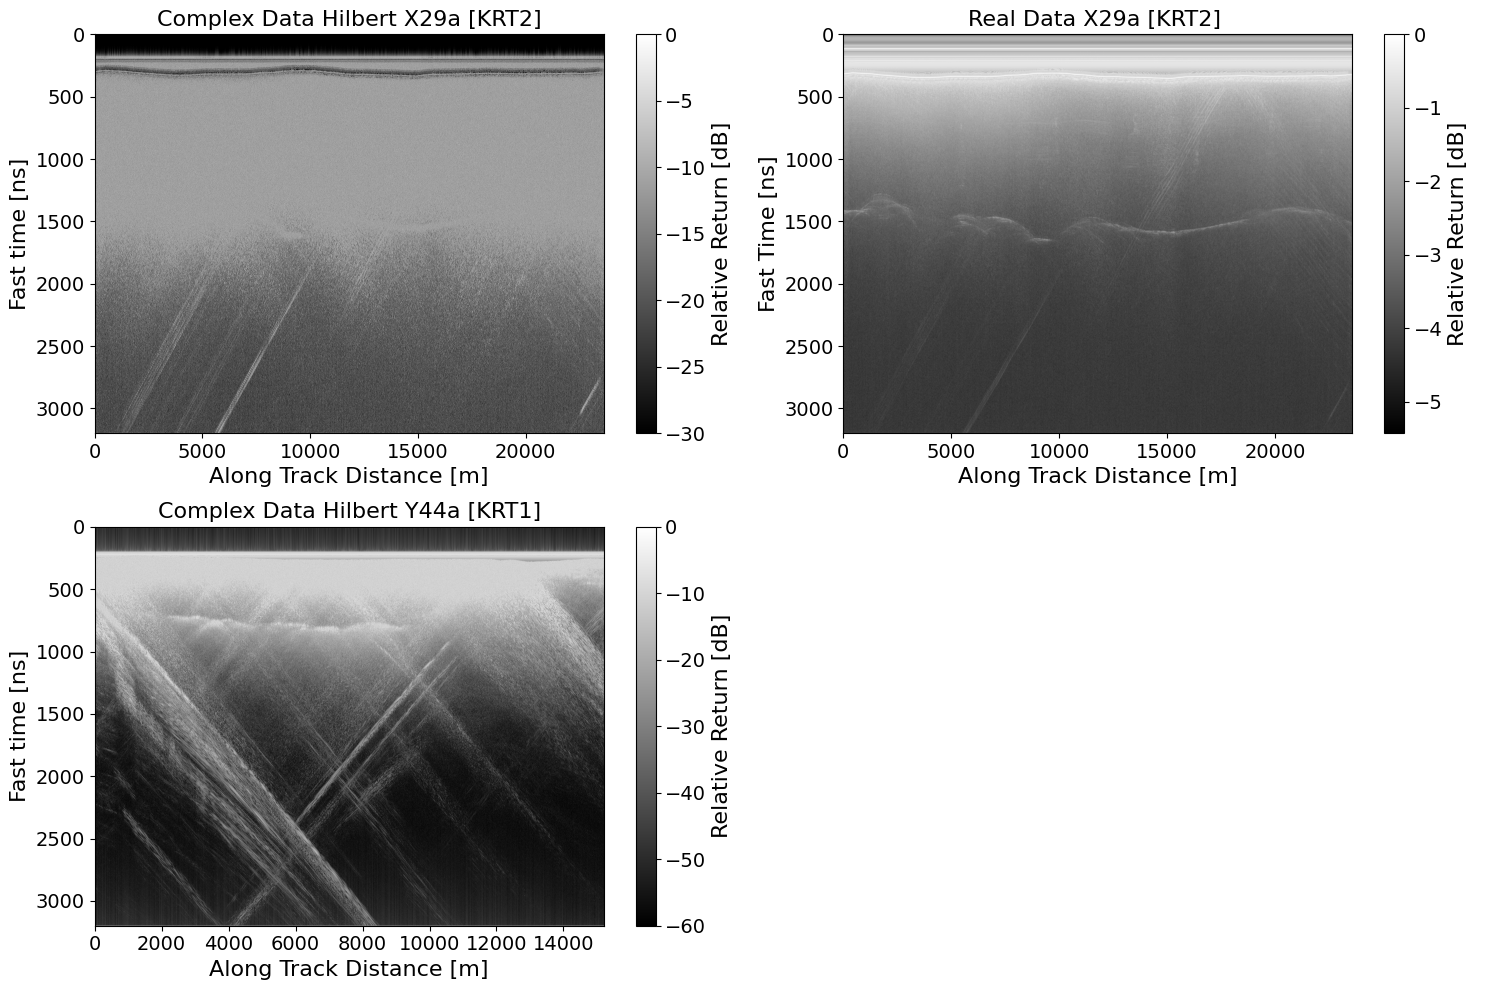

In [29]:
# Compare plots of X29a
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
ax1, ax2, ax3, ax4 = axs.ravel()
plot_radargram_xsect(ax1, analytic, vmin=-30, vmax=0)

amp = x29a_18_19.data
eps = 1e-20 
amp = amp / np.max(amp)
rad_db = 20 * np.log10(amp + eps)
im = ax2.imshow(rad_db, aspect='auto', cmap='gray', extent=[dist_along_track[0], dist_along_track[-1], x29a_18_19.travel_time[-1]/20, x29a_18_19.travel_time[0]/20])
cb = fig.colorbar(im, ax=ax2)
cb.set_label('Relative Return [dB]', fontsize=16)
ax2.set_xlabel('Along Track Distance [m]',fontsize=16)
ax2.set_ylabel('Fast Time [ns]',fontsize=16)
ax2.tick_params(labelsize=14)
cb.ax.tick_params(labelsize=14)

im1 = ax3.imshow(
    rad_db_y44a.T,
    aspect='auto',
    cmap='gray',
    vmin=-60,
    vmax=0
)

cb1 = fig.colorbar(im1, ax=ax3, label="Relative Return [dB]")
ax3.set_ylabel("Fast time [ns]",fontsize=16)
ax3.set_xlabel("Along Track Distance [m]",fontsize=16)
ax3.tick_params(labelsize=14)
cb1.ax.tick_params(labelsize=14)
cb1.set_label("Relative Return [dB]", fontsize=16)



ax1.set_title('Complex Data Hilbert X29a [KRT2]', fontsize=16)
ax2.set_title('Real Data X29a [KRT2] ', fontsize=16)
ax3.set_title('Complex Data Hilbert Y44a [KRT1]', fontsize=16)

# Get rid of ax4
ax4.axis('off')

fig.subplots_adjust(hspace=0.5) 
fig.tight_layout()
fig.savefig('X29a_Y44a_Comparison.png', dpi=300)


In [142]:
# Plot amp and phase together
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
eps = 1e-20
amp = np.abs(analytic)  
amp = amp / np.max(amp)
rad_db = 20 * np.log10(amp + eps)
im1 = ax1.imshow(
    rad_db.T,
    aspect='auto',
    cmap='gray',
)
im2 = ax2.imshow(
    np.angle(analytic).T,
    aspect='auto',
    cmap='twilight'
)

cb1 = fig.colorbar(im1, ax=ax1, label="Amplitude [dB]")
cb2 = fig.colorbar(im2, ax=ax2, label="Phase [Radians]")
fig.tight_layout()
ax1.set_ylabel("Fast time [ns]",fontsize=16)
ax1.set_xlabel("Along Track Distance [m]",fontsize=16)
ax2.set_ylabel("Fast time [ns]",fontsize=16)
ax2.set_xlabel("Along Track Distance [m]",fontsize=16)
ax1.tick_params(labelsize=14)
ax2.tick_params(labelsize=14)
cb1.ax.tick_params(labelsize=14)
cb2.ax.tick_params(labelsize=14)
cb1.set_label("Relative Return [dB]", fontsize=16)
cb2.set_label("Phase [Radians]", fontsize=16)

#for ax in [ax1, ax2]:
#    ax.set_xlim(8000, 10000)
#    ax.set_ylim(1000, 500)


fig.tight_layout()
#plt.savefig("UTIG_David_Y44a.png", dpi=300, bbox_inches='tight')



Error in callback <function _draw_all_if_interactive at 0x787a0ec1cb80> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7879d58537e0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

(200, 1000)
(800, 5000)


/tmp/ipykernel_1965/625776242.py:39: UserWarning: Adding colorbar to a different Figure <Figure size 2000x600 with 4 Axes> than <Figure size 1000x600 with 2 Axes> which fig.colorbar is called on.
  cb = fig.colorbar(im1, ax=ax, label="Relative Return [dB]")


"\nax.vlines(12000, 1450, 1650, colors='red', linestyles='-')\nax.vlines(14000, 1450, 1650, colors='red', linestyles='-')\nax.hlines(1450, 12000, 14000, colors='red', linestyles='-')\nax.hlines(1650, 12000, 14000, colors='red', linestyles='-')\n\nax.vlines(15000, 1450, 1650, colors='orange', linestyles='-')\nax.vlines(17000, 1450, 1650, colors='orange', linestyles='-')\nax.hlines(1450, 15000, 17000, colors='orange', linestyles='-')\nax.hlines(1650, 15000, 17000, colors='orange', linestyles='-')\n"

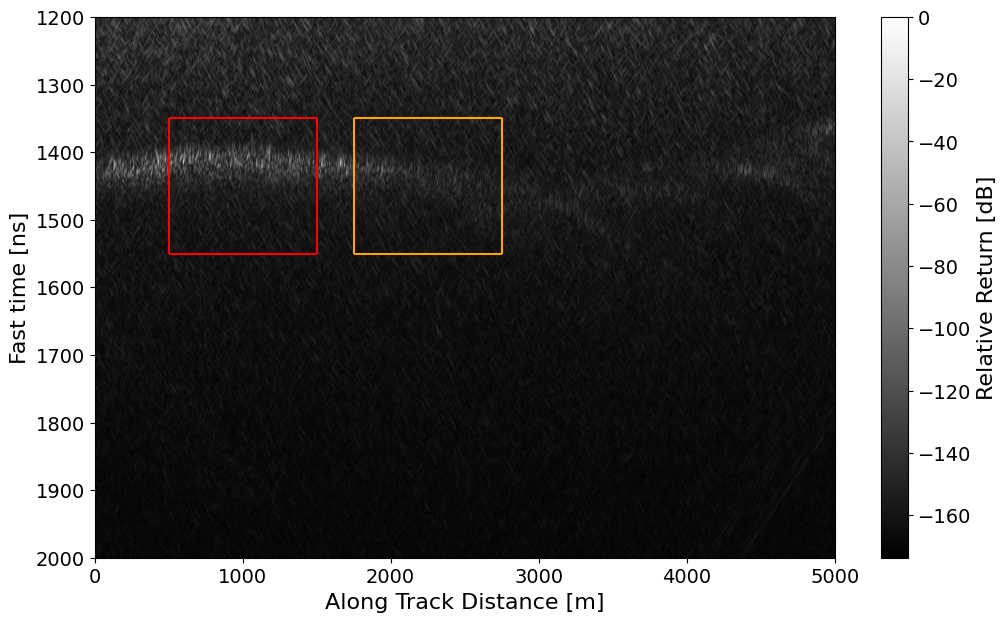

In [144]:
# Transform into doppler spectra
# x,y = [Length, Time] -> [Length, Frequency]

# Just take the portion with the bed, cut to 500 to 1000 in y, and 2000 to 10000 in x
data = analytic.T

start_y = 1200
end_y = 2000
start_x = 0
end_x = 5000

start_y_i1 = 1350
end_y_i1 = 1550
start_x_i1 = 500
end_x_i1 = 1500

start_y_i2 = 1350
end_y_i2 = 1550
start_x_i2 = 1750
end_x_i2 = 2750

data_for_plot = data[start_y:end_y:,start_x:end_x]
data_for_fft = data[start_y_i1:end_y_i1:,start_x_i1:end_x_i1]
print(data_for_fft.shape)
data = data_for_plot - np.mean(data_for_plot, axis=0, keepdims=True)
print(data.shape)
data_fft = np.fft.fftshift(np.fft.fft(data_for_fft, axis=1), axes=1)
# Make freq axis
t = utig_radargram['time'] 
t_sec = (t - t[0]).astype('timedelta64[ns]').astype(np.float64) * 1e-9
dt_slow = np.median(np.diff(t_sec.compute()))
n_slow = data.shape[1]
freq = np.fft.fftshift(
    np.fft.fftfreq(n_slow, d=dt_slow)
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.imshow(np.abs(data), aspect='auto', cmap='gray',extent=[start_x, end_x, end_y, start_y])
cb = fig.colorbar(im1, ax=ax, label="Relative Return [dB]")
fig.tight_layout()
ax.set_ylabel("Fast time [ns]",fontsize=16)
ax.set_xlabel("Along Track Distance [m]",fontsize=16)
ax.tick_params(labelsize=14)
cb.ax.tick_params(labelsize=14)
cb.set_label("Relative Return [dB]", fontsize=16)

# Box around center ofstart_y = 1200end_y = 2000start_x = 10000end_x = 20000

ax.vlines(start_x_i1, start_y_i1, end_y_i1, colors='red', linestyles='-')
ax.vlines(end_x_i1, start_y_i1, end_y_i1, colors='red', linestyles='-')
ax.hlines(start_y_i1, start_x_i1, end_x_i1, colors='red', linestyles='-')
ax.hlines(end_y_i1, start_x_i1, end_x_i1, colors='red', linestyles='-')

ax.vlines(start_x_i2, start_y_i2, end_y_i2, colors='orange', linestyles='-')
ax.vlines(end_x_i2, start_y_i2, end_y_i2, colors='orange', linestyles='-')
ax.hlines(start_y_i2, start_x_i2, end_x_i2, colors='orange', linestyles='-')
ax.hlines(end_y_i2, start_x_i2, end_x_i2, colors='orange', linestyles='-')

"""
ax.vlines(12000, 1450, 1650, colors='red', linestyles='-')
ax.vlines(14000, 1450, 1650, colors='red', linestyles='-')
ax.hlines(1450, 12000, 14000, colors='red', linestyles='-')
ax.hlines(1650, 12000, 14000, colors='red', linestyles='-')

ax.vlines(15000, 1450, 1650, colors='orange', linestyles='-')
ax.vlines(17000, 1450, 1650, colors='orange', linestyles='-')
ax.hlines(1450, 15000, 17000, colors='orange', linestyles='-')
ax.hlines(1650, 15000, 17000, colors='orange', linestyles='-')
"""

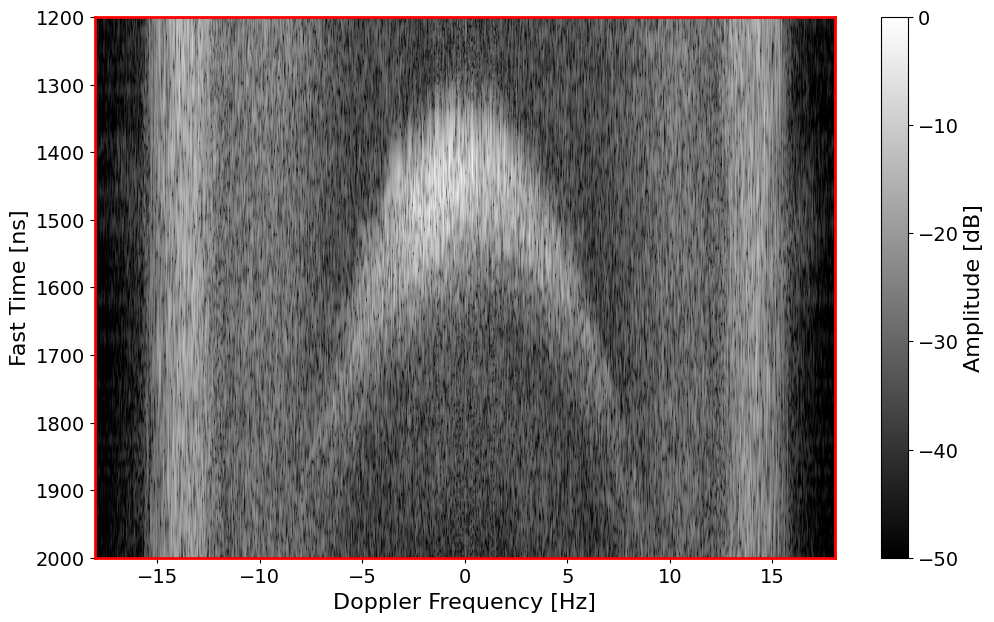

In [145]:
# Plot real part of fourier transformed data [i.e, doppler spectra] 
# Plot in dB

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

eps = 1e-20
amp = np.abs(data_fft)  
amp = amp / np.max(amp)
rad_db = 20 * np.log10(amp + eps)
im = ax.imshow(
    (rad_db),
    aspect='auto',
    cmap='gray',
    origin='lower',
    extent = [ freq[0], freq[-1],start_y, end_y],
    vmin=-50, vmax=0
)
ax.invert_yaxis()
cb = fig.colorbar(im, ax=ax, label="Amplitude [dB]")
fig.tight_layout()
ax.set_ylabel("Fast Time [ns]",fontsize=16)
ax.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
ax.tick_params(labelsize=14)
cb.ax.tick_params(labelsize=14)
cb.set_label("Amplitude [dB]", fontsize=16)

# Red axes border
for spine in ax.spines.values():
    spine.set_edgecolor('red')
    spine.set_linewidth(2)

In [153]:
x_at = utig_radargram['distance'].compute().values  # meters
dx = np.median(np.diff(x_at))
print("Along-track spacing:", dx, "m")

win_m = 1000.0     # window length [m]
ovlp_m = 500.0     # overlap [m]
win_n = int(win_m / dx)
step_n = int((win_m - ovlp_m) / dx)
print("Window samples:", win_n)
print("Step samples:", step_n)

dt_slow = np.median(np.diff(
    (utig_radargram['time'] - utig_radargram['time'][0])
    .astype('timedelta64[ns]')
    .astype(np.float64)
    .compute()
)) * 1e-9

freq = np.fft.fftshift(
    np.fft.fftfreq(win_n, d=dt_slow)
)


Along-track spacing: 1.0 m
Window samples: 1000
Step samples: 500


In [119]:
x_at

array([0.0000e+00, 1.0000e+00, 2.0000e+00, ..., 2.2226e+04, 2.2227e+04,
       2.2228e+04], shape=(22229,))

In [154]:
from scipy.signal.windows import hann
data = analytic.T
start_y = 1200
end_y = 1800
start_x = 10000
end_x = 22500

start_y = 1200
end_y = 2000
start_x = 0
end_x = 10000


data_for_plot = data[start_y:end_y:,start_x:end_x]
x_at = utig_radargram['distance'].compute().values  # meters
x_at = x_at[start_x:end_x]
data = data_for_plot - np.mean(data_for_plot, axis=0, keepdims=True)
window = hann(win_n)

doppler_cubes = []     # list of [range, doppler]
x_centers = []         # along-track center positions

for start in range(0, data.shape[1] - win_n + 1, step_n):
    stop = start + win_n

    # Extract slow-time window
    data_win = data[:, start:stop]

    # Apply slow-time window
    data_win = data_win * window[None, :]

    # Doppler FFT
    fft_win = np.fft.fftshift(
        np.fft.fft(data_win, axis=1),
        axes=1
    )

    doppler_cubes.append(fft_win)

    # Store center along-track distance
    x_centers.append(np.mean(x_at[start:stop]))


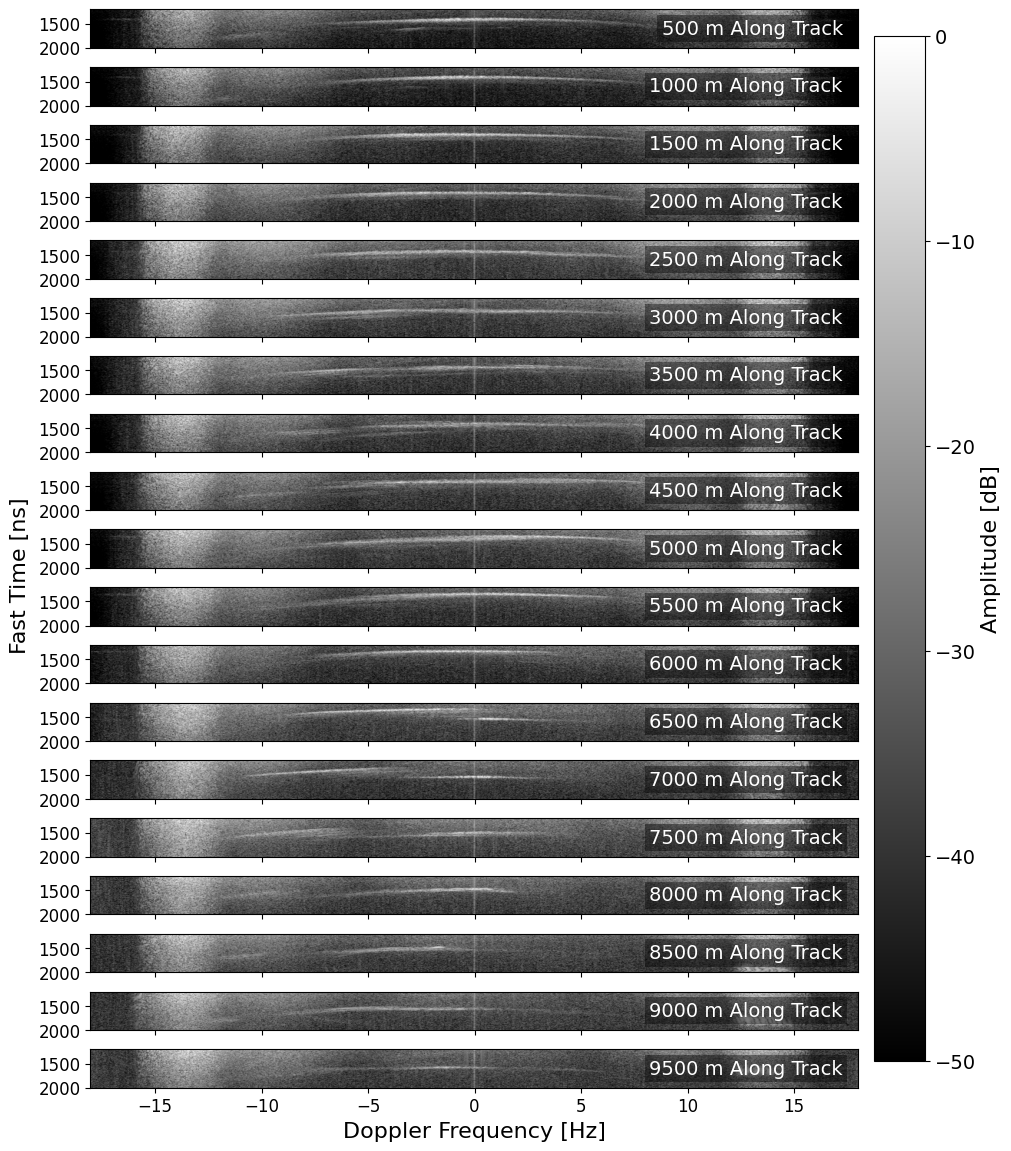

In [155]:
eps = 1e-20
doppler_db = []
for cube in doppler_cubes:
    amp = np.abs(cube)  
    amp = amp / np.max(amp)
    db = 20 * np.log10(amp + eps)
    doppler_db.append(db)

n = len(doppler_db)


fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(10, 0.6 * n),
    sharex=True,
    constrained_layout=True,
    gridspec_kw=dict(hspace=-0.5)
)

# Make axes iterable if n == 1
if n == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    im = ax.imshow(
        doppler_db[i],
        aspect='auto',
        origin='lower',
        extent = [ freq[0], freq[-1],start_y, end_y],
        cmap='gray',
        vmin=-50, vmax=0
    )

    ax.invert_yaxis()
    #ax.set_ylabel("Fast Time [ns]", fontsize=14)
    ax.tick_params(labelsize=12)

    # Top-right panel title
    ax.text(
        0.98, 0.5,
        f"{x_centers[i]:.0f} m Along Track",
        transform=ax.transAxes,
        ha="right",
        va="center",
        fontsize=14,
        color="white",
        bbox=dict(facecolor="black", alpha=0.4, edgecolor="none", pad=3)
    )

# X label only on bottom panel
axes[-1].set_xlabel("Doppler Frequency [Hz]", fontsize=16)

# Single shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    pad=0.02,
    shrink=0.95
)
cbar.set_label("Amplitude [dB]", fontsize=16)
cbar.ax.tick_params(labelsize=14)
fig.supylabel("Fast Time [ns]", fontsize=16)

plt.show()


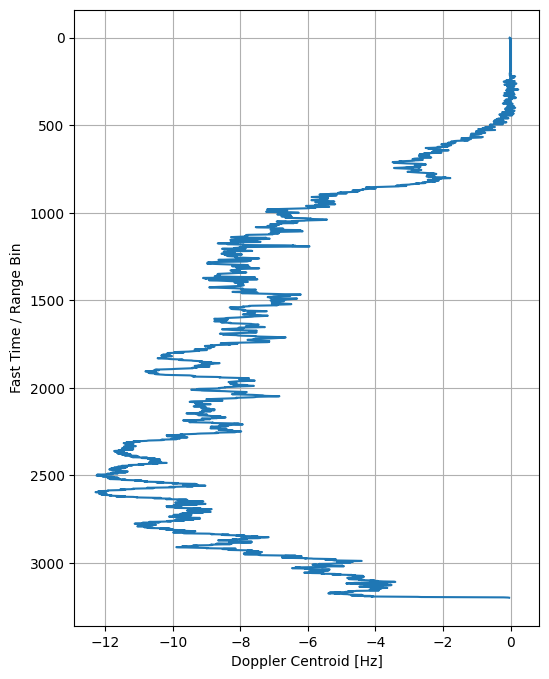

In [ ]:
# GPT Interpertation - Look at zero-Doppler reference by examining Doppler centroid as function of range
power = np.abs(data_fft)**2

doppler_centroid = (
    np.sum(freq[None, :] * power, axis=1) /
    np.sum(power, axis=1)
)

fig, ax = plt.subplots(figsize=(6, 8))
ax.plot(doppler_centroid, np.arange(data.shape[0]))
ax.invert_yaxis()
ax.set_xlabel("Doppler Centroid [Hz]")
ax.set_ylabel("Fast Time / Range Bin")
ax.grid()
plt.show()

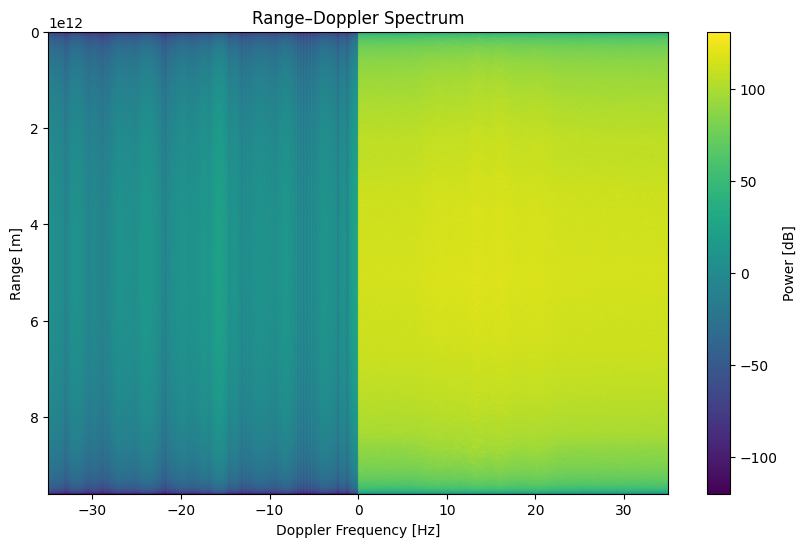

In [ ]:
# meters
dx = float(analytic_xr.distance.diff("distance").median())

# m/s (example – replace with real value)
platform_velocity = 70.0

dt_slow = dx / platform_velocity

# Remove slow-time mean (clutter suppression)
analytic_demean = analytic_xr - analytic_xr.mean("distance")

# Window in slow time
window = xr.DataArray(
    np.hanning(analytic_xr.sizes["distance"]),
    dims="distance",
    coords={"distance": analytic_xr.distance},
)

analytic_win = analytic_demean * window

RD = xr.apply_ufunc(
    np.fft.fft,
    analytic_win,
    input_core_dims=[["distance"]],
    output_core_dims=[["doppler"]],
    kwargs={"axis": 0},
)

RD = xr.apply_ufunc(
    np.fft.fftshift,
    RD,
    input_core_dims=[["doppler"]],
    output_core_dims=[["doppler"]],
    kwargs={"axes": 0},
)

RD_power = np.abs(RD) ** 2

Nd = analytic_xr.sizes["distance"]

doppler_freq = np.fft.fftshift(
    np.fft.fftfreq(Nd, d=dt_slow)
)

RD_power = RD_power.assign_coords(
    doppler=("doppler", doppler_freq)
)

c = 3e8  # or ice velocity if already converted
range_m = (analytic_xr.fast_time * c / 2).data

RD_power = RD_power.assign_coords(
    range=("fast_time", range_m)
)

plt.figure(figsize=(10, 6))

img = RD_power.T.data
img = 10 * np.log10(img + 1e-12)

plt.imshow(
    img,
    aspect="auto",
    extent=[
        float(RD_power.doppler.min()),
        float(RD_power.doppler.max()),
        float(RD_power.range.max()),
        float(RD_power.range.min()),
    ],
)

plt.xlabel("Doppler Frequency [Hz]")
plt.ylabel("Range [m]")
plt.colorbar(label="Power [dB]")
plt.title("Range–Doppler Spectrum")
plt.show()


In [ ]:
analytic_xr = xr.DataArray(
    analytic,
    dims=("distance", "fast_time"),
    coords={
        "distance": utig_radargram.distance,
        "fast_time": utig_radargram.fast_time
    }
)

z = analytic_xr - analytic_xr.mean(axis=0, keepdims=True)

w = np.hanning(z.shape[0])[:, None]
z_win = z * w
RD = np.fft.fftshift(
    np.fft.fft(z_win, axis=0),
    axes=0
)
v = 200.0        # m/s (use real HeRa velocity)
dx = 1.0         # m slow-time spacing

fs = v / dx
f_d = np.fft.fftshift(np.fft.fftfreq(RD.shape[0], d=1/fs))

RD_db = 20 * np.log10(np.abs(RD) + 1e-6)

plt.figure(figsize=(9, 6))
plt.imshow(
    RD_db.T,           # transpose so fast time is vertical
    aspect='auto',
    cmap='inferno',
    extent=[
        f_d[0], f_d[-1],
        analytic_xr.fast_time[-1], analytic_xr.fast_time[0]
    ]
)
plt.xlabel("Doppler frequency (Hz)")
plt.ylabel("Fast time (range)")
plt.title("Range–Doppler Map")
plt.colorbar(label="Power (dB)")
plt.show()

"""
z_r = analytic_xr[:, 1000:2000].mean(axis=0)
z_r = z_r - np.mean(z_r)
w = np.hanning(z_r.size)
z_r = z_r * w
doppler = np.fft.fftshift(
    np.fft.fft(z_r, axis=0)
)
plt.plot(20*np.log10(np.abs(doppler)+1e-6))
#z_r = analytic_xr.isel(fast_time=300)
#z_r = z_r - z_r.mean('distance')
#doppler = np.fft.fftshift(np.fft.fft(z_r))
#plt.plot(20*np.log10(np.abs(doppler)+1e-6))
"""

AlignmentError: cannot reindex or align along dimension 'distance' because of conflicting dimension sizes: {1, 15204} (note: an index is found along that dimension with size=15204)

Text(0, 0.5, 'Fast Time [usec?]')

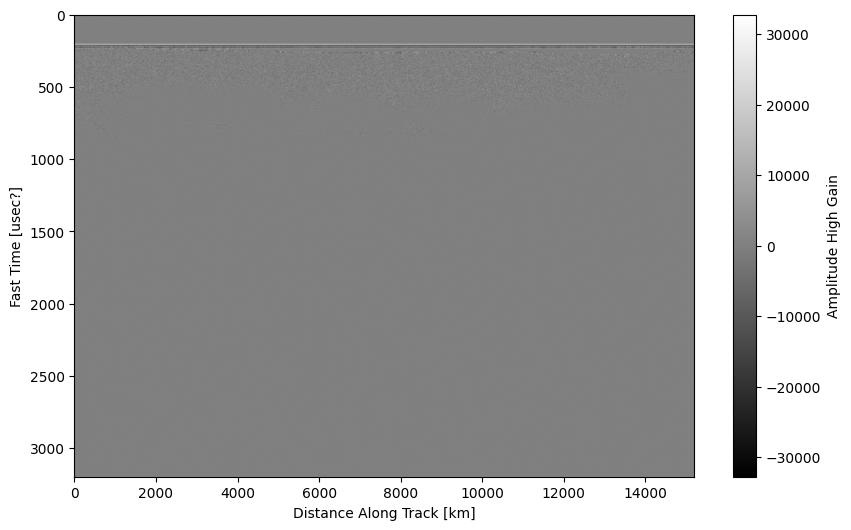

In [ ]:
# Plot utig radargram
fig, ax = plt.subplots(figsize=(10,6))
im = ax.imshow(utig_radargram['bxds1'].T, aspect='auto', cmap='gray')
fig.colorbar(im, ax=ax, label='Amplitude High Gain')
ax.set_xlabel('Distance Along Track [km]')
ax.set_ylabel('Fast Time [usec?]')


In [ ]:
utig_radargram['fasttime'][].values

array([0, 0, 0, ..., 0, 0, 0], shape=(10926,), dtype='timedelta64[ns]')

In [ ]:
# Load basemap stuff
# Get new RINGS Gl
rings_grounded_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/RINGS_2022/RINGS_grounded_2022.shp'
rings_coastline_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/RINGS_2022/RINGS_coastline_2022.shp'
rings_grounded_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/RINGS_2022/RINGS_grounded_2022.shp'
rings_iceshelves_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/RINGS_2022/RINGS_iceshelves_2022.shp'
rings_islands_ADD = '/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/RINGS_2022/RINGS_islands_ADD.shp'
rings_polygonmask = '/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/RINGS_2022/RINGS_polygonmask.shp'

paths = [
    rings_coastline_path,
    rings_grounded_path,
    rings_iceshelves_path,
    rings_islands_ADD,
    rings_polygonmask,
]

records_full = []
shapes_full = []
field_names_full = []

for path in paths:
    sf = shapefile.Reader(path)
    records_full.append(sf.records())
    shapes_full.append(sf.shapes())
    field_names_full.append([f[0] for f in sf.fields[1:]])

def plot_RINGS_shapefile(
    records_list: list[shapefile._Record],
    shapes_list: list[shapefile.Shape],
    field_names_list: list[str],
    ax ,
    colors: list[str],
    transform,
    fill: bool = False,
    zorder: int = 2,
    linewidth: int = 2,
) -> None:
    """
    Plots the given records and shapes on axis ax.

    Parameters
    ----------
    records : list[shapefile._Record]
        Shapely record containing shape classification
    shapes : list[shapefile.Shape]
        Shapely shape points
    ax : cartopy.mpl.geoaxes.GeoAxes
        Axes to polot on
    colors : list[str]
       [Grounded ice color, Ice Shelf color]; Must be length 2
    """
    for records, shapes, field_names in zip(records_list, shapes_list, field_names_list):
        for record, shape in zip(records, shapes):
            rec_dict = dict(zip(field_names, record))
            classification = rec_dict["Type"]
            points = shape.points
            parts = list(shape.parts)
            parts.append(len(points)) # Append the end index of the last part of the shapefile
            for i in range(len(parts) - 1):
                    part = points[parts[i] : parts[i + 1]]
                    if classification == "Coastline":
                        if fill:
                            ax.fill(*zip(*part), color=colors[1], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[1], linewidth=linewidth, zorder=zorder,transform=transform)
                    elif classification == "Grounded":
                        if fill:
                            ax.fill(*zip(*part), color=colors[0], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[0], linewidth=linewidth, zorder=zorder,transform=transform)
                    elif classification == "Transient":
                        if fill:
                            ax.fill(*zip(*part), color=colors[0], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[0], linewidth=linewidth, zorder=zorder,transform=transform)
                    elif classification == "Island":
                        if fill:
                            ax.fill(*zip(*part), color=colors[0], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[0], linewidth=linewidth, zorder=zorder,transform=transform)
                    else:
                        #print(f"Unknown classification: {classification}")
                        pass


#plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=inset, colors=['lightgray','white'],
#                    transform=ps71_projection, fill=True, zorder=2, linewidth=1)

#plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=ax, colors=['white','None'],
#                    transform=ps71_projection, fill=False, zorder=2, linewidth=1)


In [ ]:
#to_plot = radargrams_16_17[30:31][0][0]
#dir(to_plot)
for rad in radargrams_18_19[:]:
    to_plot = rad[0]
    print(to_plot.x_coord/10)

[67823.969 67823.271 67822.585 ... 65525.057 65523.879 65522.346]
[67778.369 67777.397 67776.359 ... 65528.833 65528.528 65528.521]
[67842.348 67841.536 67840.724 ... 65465.963 65465.776 65464.962]
[65590.    65591.04  65592.088 ... 67776.142 67776.579 67776.788]
[65414.017 65414.837 65415.648 ... 67816.869 67817.76  67818.683]
[67726.714 67725.833 67724.97  ... 65458.821 65457.896 65456.967]
[67731.472 67731.54  67731.49  ... 65377.495 65376.622 65375.764]
[65441.337 65442.14  65442.951 ... 67701.749 67702.613 67703.455]
[65363.226 65364.001 65364.77  ... 67700.813 67701.595 67702.365]
[67644.366 67643.329 67642.31  ... 65399.264 65398.479 65397.675]
[67625.207 67624.441 67623.706 ... 65302.852 65302.065 65301.274]
[65455.517 65456.552 65457.588 ... 67662.852 67663.806 67664.783]
[67642.435 67641.457 67640.478 ... 65335.955 65335.495 65335.262]
[65332.527 65333.437 65334.33  ... 67710.75  67711.62  67712.374]
[67588.272 67587.323 67586.363 ... 65304.511 65303.549 65302.599]
[65305.294

In [ ]:
# Load Lake Cheongsuk shapefile
sld_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/_Semesters/25FA/KOPRI/SLD2'
pathA = sld_path + '/SLD2-A.shp'
pathB = sld_path + '/SLD2-B.shp'
pathC = sld_path + '/SLD2-C.shp'

xs = []
ys = []
for path in [pathA, pathB, pathC]:
    sf = shapefile.Reader(path)
    shapes = sf.shapes()
    for shp in shapes:
        points = shp.points
        x = [p[0] for p in points]
        y = [p[1] for p in points]
    xs.append(x)
    ys.append(y)


In [ ]:
from pyproj import CRS, Transformer
def xy2ll(x: list[float], y: list[float]) -> tuple[list[float], list[float]]:
    """
    Transform coordinates from Antarctic Polar Stereographic coordinates (x, y)
    to output geodetic coordinates (lon, lat).
    Can also take single floats.

    Parameters
    ----------
    x: list[float]
       Antarctic Polar Stereographic (EPSG:3031) x
    y: list[float]
       Antarctic Polar Stereographic (EPSG:3031) y

    Returns
    -------
    lon: list[float]
         Geodetic longitude in EPSG:4326
    lat: list[float]
         Geodetic latitude in EPSG:4326
    """
    crs_ll = CRS("EPSG:4326")
    crs_xy = CRS("EPSG:3031")
    xy_to_ll = Transformer.from_crs(crs_xy, crs_ll, always_xy=True)
    lon, lat = xy_to_ll.transform(x, y)
    return lon, lat

In [ ]:
lon, lat = xy2ll(xs[0][0], ys[0][0])
print(lon, lat)

155.46287226044208 -75.38631843716142


[678239.69 678232.71 678225.85 ... 655250.57 655238.79 655223.46]
[677783.69 677773.97 677763.59 ... 655288.33 655285.28 655285.21]
[678423.48 678415.36 678407.24 ... 654659.63 654657.76 654649.62]
[655900.   655910.4  655920.88 ... 677761.42 677765.79 677767.88]
[654140.17 654148.37 654156.48 ... 678168.69 678177.6  678186.83]
[677267.14 677258.33 677249.7  ... 654588.21 654578.96 654569.67]
[677314.72 677315.4  677314.9  ... 653774.95 653766.22 653757.64]
[654413.37 654421.4  654429.51 ... 677017.49 677026.13 677034.55]
[653632.26 653640.01 653647.7  ... 677008.13 677015.95 677023.65]
[676443.66 676433.29 676423.1  ... 653992.64 653984.79 653976.75]
[676252.07 676244.41 676237.06 ... 653028.52 653020.65 653012.74]
[654555.17 654565.52 654575.88 ... 676628.52 676638.06 676647.83]
[676424.35 676414.57 676404.78 ... 653359.55 653354.95 653352.62]
[653325.27 653334.37 653343.3  ... 677107.5  677116.2  677123.74]
[675882.72 675873.23 675863.63 ... 653045.11 653035.49 653025.99]
[653052.94

(-1605000.0, -1320000.0)

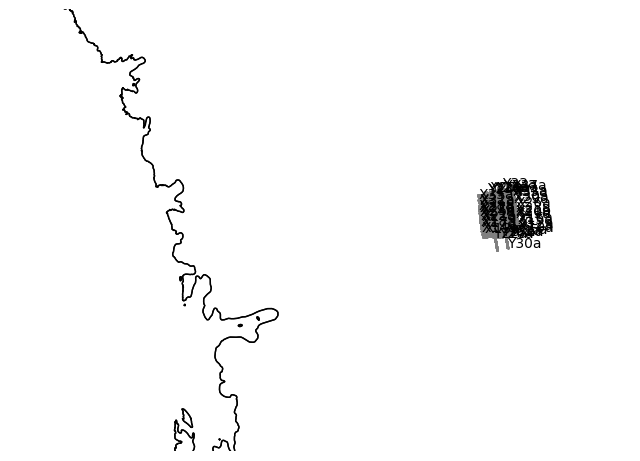

In [ ]:
# Make map showing names of each radargram
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': ps71_projection})

bbox = [350000,-1605000,750000,-1320000] #David_SGL2_full
names = [path.split('/')[-1].split('.')[0] for path in file_paths_18_19]


plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=ax, colors=['black','None'],
                    transform=ps71_projection, fill=False, zorder=2, linewidth=1)

ax.patch.set_facecolor("none")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

for radargram in radargrams_18_19[:]:
    ax.scatter(radargram[0].x_coord*1, radargram[0].y_coord*1, s=0.1, color='gray', zorder=3)
    ax.text(radargram[0].x_coord[0]*1, radargram[0].y_coord[0]*1, names[radargrams_18_19.index(radargram)], color='black', fontsize=10, transform=ps71_projection, zorder=4)

for x, y in zip(xs, ys):
    ax.plot(x, y, color='blue', linewidth=1.5)

ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])

    

In [ ]:
# Choose radargram and get along track distance
# Get radargram at index of 'XXX' in names
to_plot = radargrams_18_19[names.index('X19a')][0]
x_start = to_plot.x_coord[0]
y_start = to_plot.y_coord[0]
dist_along_track = np.sqrt((to_plot.x_coord/10 - x_start)**2 + (to_plot.y_coord/10 - y_start)**2)

(-1605000.0, -1320000.0)

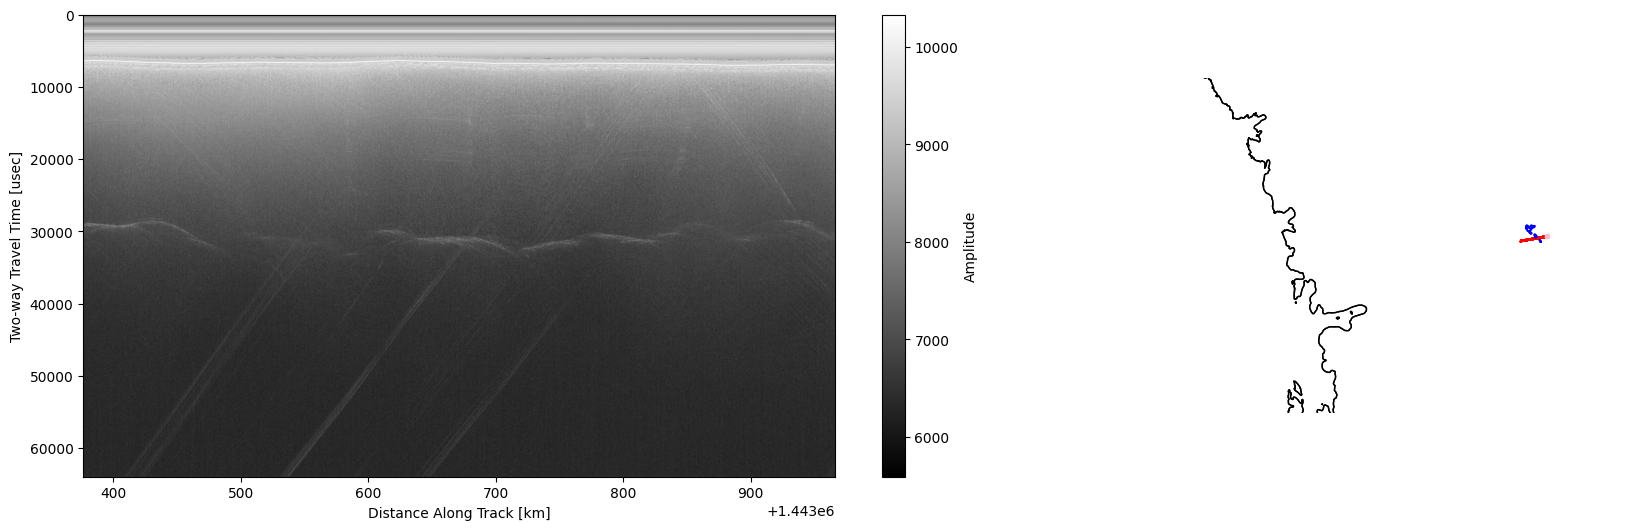

In [ ]:
# Plot two panel plot of radargram and position in map of Antarctica
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig = plt.figure(figsize=(20,6))
gs = fig.add_gridspec(1, 2, width_ratios=[2, 1])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], projection=ps71_projection)

### AX1 ###

im = ax1.imshow(to_plot.data, aspect='auto', cmap='gray', extent=[dist_along_track[0], dist_along_track[-1], to_plot.travel_time[-1], to_plot.travel_time[0]])
fig.colorbar(im, ax=ax1, label='Amplitude')
ax1.set_xlabel('Distance Along Track [km]')
ax1.set_ylabel('Two-way Travel Time [usec]')




### AX2 ###
bbox = [350000,-1605000,750000,-1320000] #David_SGL2_full


plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=ax2, colors=['black','None'],
                    transform=ps71_projection, fill=False, zorder=2, linewidth=1)

ax2.patch.set_facecolor("none")
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.set_xticks([])
ax2.set_yticks([])


for radargram in radargrams_18_19[:]:
    ax.scatter(radargram[0].x_coord*1, radargram[0].y_coord*1, s=0.1, color='gray', zorder=3)


ax2.scatter(to_plot.x_coord, to_plot.y_coord, s=0.1, color='red', transform=ps71_projection, zorder=4)
ax2.scatter(to_plot.x_coord[0], to_plot.y_coord[0], s=10, color='pink', transform=ps71_projection, zorder=5)


for x, y in zip(xs, ys):
    ax2.plot(x, y, color='blue', linewidth=1.5, zorder=6)

ax2.set_xlim(bbox[0],bbox[2])
ax2.set_ylim(bbox[1],bbox[3])


In [ ]:
to_plot.data.shape

(3200, 2692)

In [ ]:
# Choose radargram and get along track distance
# Get radargram at index of 'XXX' in names
to_plot = radargrams_16_17[names.index('GL0328c')][0]
x_start = to_plot.x_coord[0]/10
y_start = to_plot.y_coord[0]/10
dist_along_track = np.sqrt((to_plot.x_coord/10 - x_start)**2 + (to_plot.y_coord/10 - y_start)**2)

NameError: name 'names' is not defined

In [ ]:
print(type(radargrams_16_17_Ju[0][0].data[0][0]))

<class 'numpy.float32'>


(-1605000.0, -1320000.0)

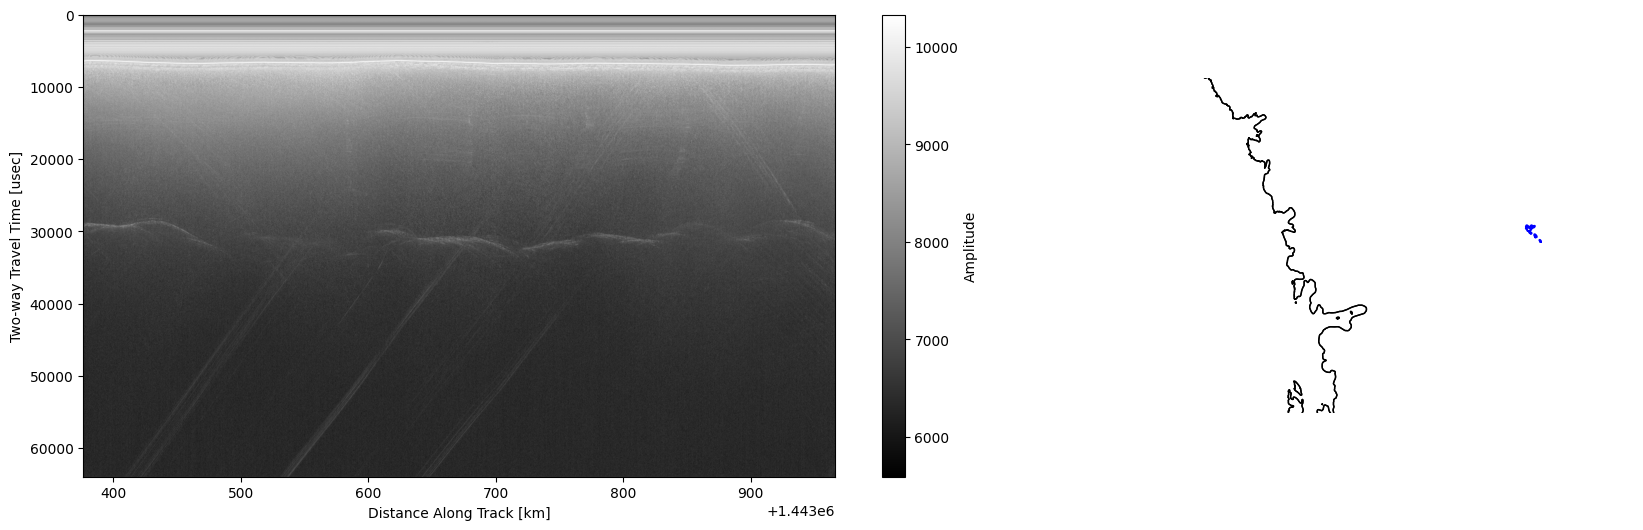

In [ ]:
# Plot two panel plot of radargram and position in map of Antarctica
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig = plt.figure(figsize=(20,6))
gs = fig.add_gridspec(1, 2, width_ratios=[2, 1])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], projection=ps71_projection)

### AX1 ###

im = ax1.imshow(to_plot.data, aspect='auto', cmap='gray', extent=[dist_along_track[0], dist_along_track[-1], to_plot.travel_time[-1], to_plot.travel_time[0]])
fig.colorbar(im, ax=ax1, label='Amplitude')
ax1.set_xlabel('Distance Along Track [km]')
ax1.set_ylabel('Two-way Travel Time [usec]')




### AX2 ###
bbox = [350000,-1605000,750000,-1320000] #David_SGL2_full


plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=ax2, colors=['black','None'],
                    transform=ps71_projection, fill=False, zorder=2, linewidth=1)

ax2.patch.set_facecolor("none")
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.set_xticks([])
ax2.set_yticks([])

for radargram in radargrams_16_17:
    ax2.scatter(radargram[0].x_coord*100, radargram[0].y_coord*100, s=0.1, color='gray', transform=ps71_projection, zorder=3)

ax2.scatter(to_plot.x_coord*100, to_plot.y_coord*100, s=0.1, color='red', transform=ps71_projection, zorder=4)
ax2.scatter(to_plot.x_coord[0]*100, to_plot.y_coord[0]*100, s=10, color='pink', transform=ps71_projection, zorder=5)


for x, y in zip(xs, ys):
    ax2.plot(x, y, color='blue', linewidth=1.5, zorder=6)

ax2.set_xlim(bbox[0],bbox[2])
ax2.set_ylim(bbox[1],bbox[3])


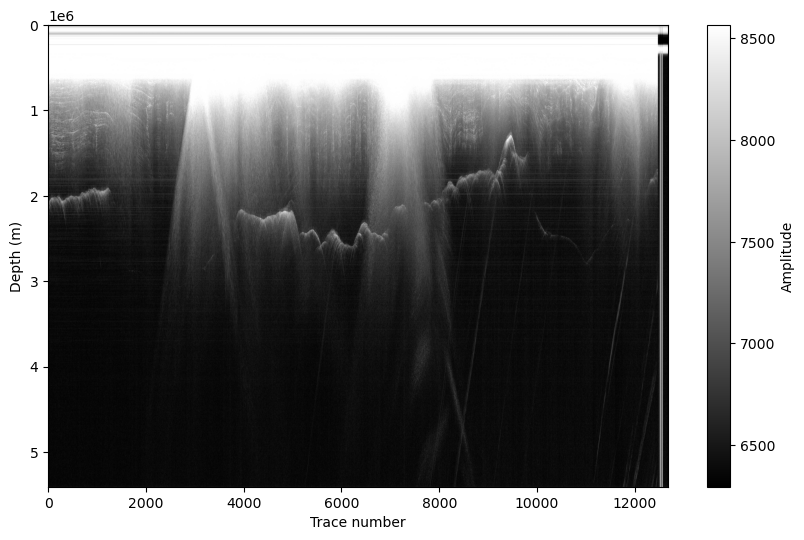

In [ ]:
test_rad_gram = radargrams_16_17[0][0]
fig, ax = plt.subplots(figsize=(10, 6))
im, xd, yd, x_range, clims = plot_radargram(test_rad_gram, ydat='depth', xdat='tnum', ax=ax, fig=fig, return_plotinfo=True)
fig.colorbar(im, ax=ax, label='Amplitude')

In [ ]:
print(dir(test_rad_gram))
test_rad_gram.chan
test_rad_gram.data.shape, test_rad_gram.data_dtype

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_get_pick_targ_info', '_parse_stodeepdata', 'adaptivehfilt', 'agc', 'attrs_guaranteed', 'attrs_optional', 'chan', 'check_attrs', 'clean_GPS', 'constant_sample_depth_spacing', 'constant_space', 'crop', 'data', 'data_dtype', 'datetime', 'decday', 'denoise', 'dist', 'dt', 'elev', 'elev_correct', 'flags', 'fn', 'get_ll', 'get_projected_coords', 'hcrop', 'hfilt', 'highpass', 'horizontal_band_pass', 'horizontalfilt', 'lat', 'long', 'lowpass', 'migrate', 'nmo', 'nmo_depth', 'output_csv', 'output_ogr', 'output_shp', 'picks', 'pressure', 'rangegain', 'restack', 'reverse', 'save', 'save_as_segy', 'snum', 'stodeep_attrs', 't_srs', 'tnum', 't

((3200, 12683), dtype('float32'))

(<Figure size 800x1200 with 1 Axes>,
 <Axes: xlabel='Amplitude', ylabel='Two way travel time (usec)'>)

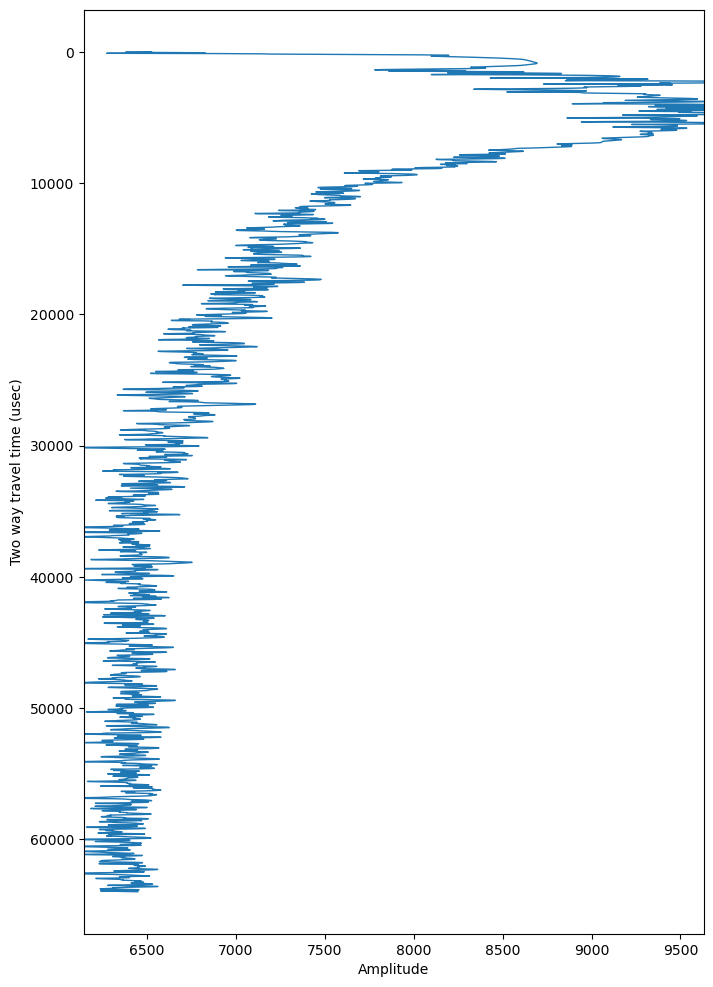

In [ ]:
# Plot trace
#test_rad_gram.vertical_band_pass(0.00001,0.01)
plot_traces(test_rad_gram,tr=100)

In [ ]:
#file_paths = [os.path.join('./_data/IPR_2016-2017', f) for f in os.listdir('./_data/IPR_2016-2017') if f.endswith('.segy')]
file_paths = [os.path.join('./_data/IPR_2018-2019', f) for f in os.listdir('./_data/IPR_2018-2019') if f.endswith('.segy')]
USEC_TO_SEC = 1e-6

In [ ]:
radargrams = [_read_segy(file_paths[i], unpack_trace_headers=True) for i in range(len(file_paths[12:13]))]


In [ ]:
print(rad.traces[0].stats.segy.trace_header.sample_interval_in_ms_for_this_trace)
print(USEC_TO_SEC)


20000

In [ ]:
for rad in radargrams[:1]:
    for tr in rad[:1].traces:
        print(tr.stats.segy)

AttribDict({'trace_header': AttribDict({'endian': '>', 'unpacked_header': None, 'trace_sequence_number_within_line': 1, 'trace_sequence_number_within_segy_file': 1, 'original_field_record_number': 1, 'trace_number_within_the_original_field_record': 1, 'energy_source_point_number': 1, 'ensemble_number': 1, 'trace_number_within_the_ensemble': 0, 'trace_identification_code': 0, 'number_of_vertically_summed_traces_yielding_this_trace': 1, 'number_of_horizontally_stacked_traces_yielding_this_trace': 1, 'data_use': 1, 'distance_from_center_of_the_source_point_to_the_center_of_the_receiver_group': 0, 'receiver_group_elevation': 182543, 'surface_elevation_at_source': 182543, 'source_depth_below_surface': 0, 'datum_elevation_at_receiver_group': 182543, 'datum_elevation_at_source': 182543, 'water_depth_at_source': 0, 'water_depth_at_group': 0, 'scalar_to_be_applied_to_all_elevations_and_depths': -100, 'scalar_to_be_applied_to_all_coordinates': -100, 'source_coordinate_x': 65414017, 'source_coord